In [1]:
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.visualization import simple_norm
from spectral_cube import SpectralCube as sc

from pybaselines import Baseline
from pybaselines.utils import gaussian, relative_difference
from pybaselines._banded_utils import PenalizedSystem
from pybaselines._weighting import _arpls

import warnings

from joblib import Parallel, delayed
from functools import partial

%matplotlib widget
plt.rcParams.update({'font.size': 16})

In [2]:
file = "../CRAFTS/South/Combined/CRAFTS_RA120_140_DEC-13_2.fits"
cube = sc.read(file).with_spectral_unit(u.km / u.s)

data = cube.unmasked_data[:, :, :].value
n_v = data.shape[0]
n_y = data.shape[1]
n_x = data.shape[2]

velocities = cube.spectral_axis.value
cube

SpectralCube with shape=(5962, 600, 800) and unit=K:
 n_x:    800  type_x: RA---CAR  unit_x: deg    range:   120.012500 deg:  139.987500 deg
 n_y:    600  type_y: DEC--CAR  unit_y: deg    range:   -12.987500 deg:    1.987500 deg
 n_s:   5962  type_s: VRAD      unit_s: km / s  range:     -599.897 km / s:     599.954 km / s

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (122.1875, -11.5625)>


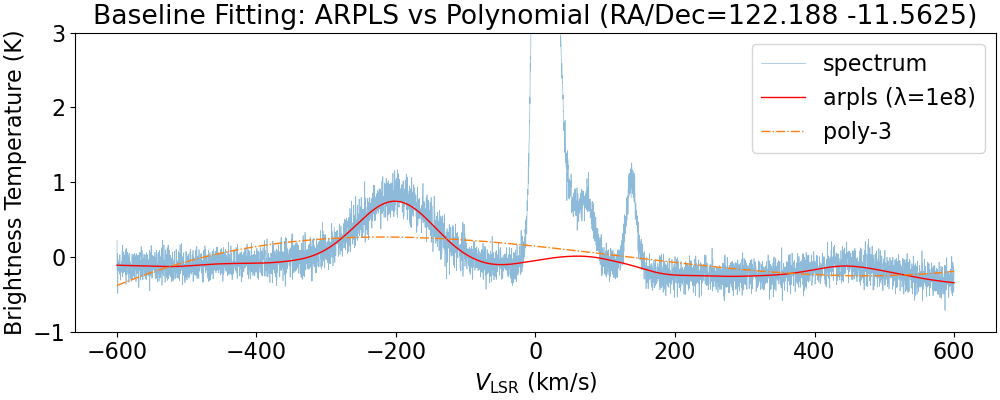

In [3]:
spectrum = data[:, 57, 712]
sky = cube.wcs.celestial.pixel_to_world(712, 57)
print(sky)

mask = (velocities < -50) | (velocities > 200)
v_masked = velocities[mask]
spec_masked = spectrum[mask]

# ARPLS method
bkg, params = Baseline(velocities).arpls(spectrum, lam=1e8)

# Polynomial method
_, params = Baseline(v_masked).poly(spec_masked, poly_order=3, return_coef=True)
# recreate the polynomial using numpy and the full x-data
baseline_poly = np.polynomial.Polynomial(params["coef"])(velocities)

fig = plt.figure(figsize=(10, 4), layout="constrained")
plt.plot(velocities, spectrum, label="spectrum", lw=0.5, alpha=0.5)
plt.plot(velocities, bkg, label="arpls (λ=1e8)", lw=1, color="red")
plt.plot(velocities, baseline_poly, "-.", label="poly-3", lw=1)
plt.legend()
plt.xlabel(r"$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$", fontsize=16)
plt.ylabel("Brightness Temperature (K)", fontsize=16)
plt.ylim(-1, 3)
plt.title(f"Baseline Fitting: ARPLS vs Polynomial (RA/Dec={sky.to_string('decimal')})")
plt.savefig("baseline_fitting_1.png", dpi=300)
plt.show()

In [4]:
def masked_arpls(y, mask=None, lam=1e8, diff_order=2, tol=1e-3, max_iter=50, weights=None):
    """A mask-aware version of the arpls algorithm."""
    len_y = len(y)
    if mask is None:
        mask = np.ones(len_y, dtype=bool)
        y_fit = y
    else:
        y_fit = 1 * y  # don't want to override the input y, so make a copy
        y_fit[~mask] = 0  # cover that case of nan values in y since 0 * nan = nan rather than 0
    if weights is None:
        weights = np.ones(len_y)
    else:
        weights = 1 * weights  # don't want to override the input weights, so make a copy
    weights[~mask] = 0
    whittaker_system = PenalizedSystem(len(y), lam=lam, diff_order=diff_order)
    for _ in range(max_iter):
        baseline = whittaker_system.solve(
            whittaker_system.add_diagonal(weights), weights * y_fit,
        )
        # need to ignore the problem regions in y since they would otherwise affect
        # the arpls weighting; could alternatively do:
        # _arpls(np.interp(x, x[mask], y[mask]), baseline) to approximate
        # the y-values, but it leads to a slightly different result
        calc_weights, exit_early = _arpls(y[mask], baseline[mask])
        if exit_early:
            break
        new_weights = np.zeros(len_y)
        new_weights[mask] = calc_weights
        if relative_difference(weights, new_weights) < tol:
            break
        weights = new_weights
    return baseline

# Mask the velocity ranges
vel_mask = (velocities < -61) | (velocities > 139)

In [5]:
# Use ARPLS seperately on positive and negative velocity ranges
spec_neg = spectrum[(velocities < -50)]
vel_neg = velocities[(velocities < -50)]
bkg_neg = Baseline(vel_neg).arpls(spec_neg, lam=1e8)[0]

spec_pos = spectrum[(velocities > 100)]
vel_pos = velocities[(velocities > 100)]
bkg_pos = Baseline(vel_pos).arpls(spec_pos, lam=1e8)[0]

# Combine the two baselines with NaNs in the masked regions
bkg_combined = np.full_like(spectrum, np.nan, dtype=float)
bkg_combined[(velocities < -50)] = bkg_neg
bkg_combined[(velocities > 100)] = bkg_pos

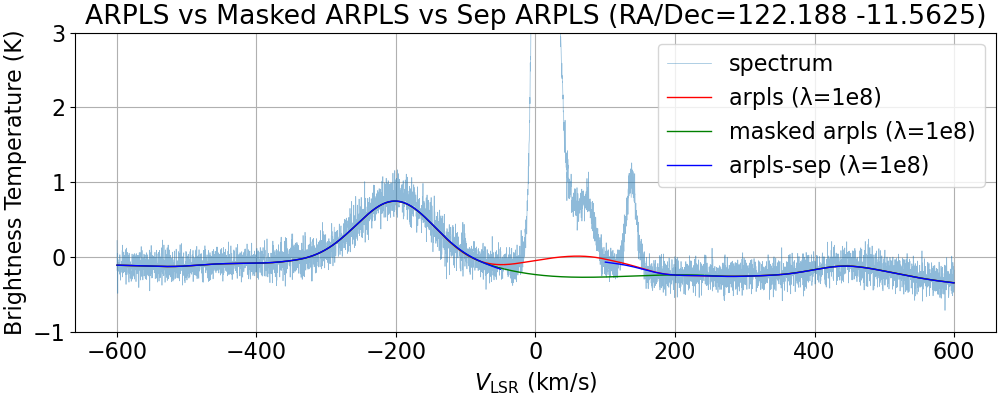

In [ ]:
# ARPLS method vs Masked ARPLS method vs Separated ARPLS method

bkg_masked = masked_arpls(spectrum, mask=mask, lam=1e8)

fig = plt.figure(figsize=(10, 4), layout="constrained")
plt.plot(velocities, spectrum, label='spectrum', lw=0.5, alpha=0.5)
plt.plot(velocities, bkg, label='arpls (λ=1e8)', lw=1, color='red')
plt.plot(velocities, bkg_masked, label='masked arpls (λ=1e8)', lw=1, color='green')
plt.plot(velocities, bkg_combined, label='sep arpls (λ=1e8)', lw=1, color='blue')
plt.legend()
plt.xlabel(r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$')
plt.ylabel('Brightness Temperature (K)')
plt.ylim(-1, 3)
plt.title(f'ARPLS vs Masked ARPLS vs Sep ARPLS (RA/Dec={sky.to_string("decimal")})')
plt.grid()
plt.savefig('baseline_fitting_2.png', dpi=300)
plt.show()

<SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (130.1125, -7.1625)>


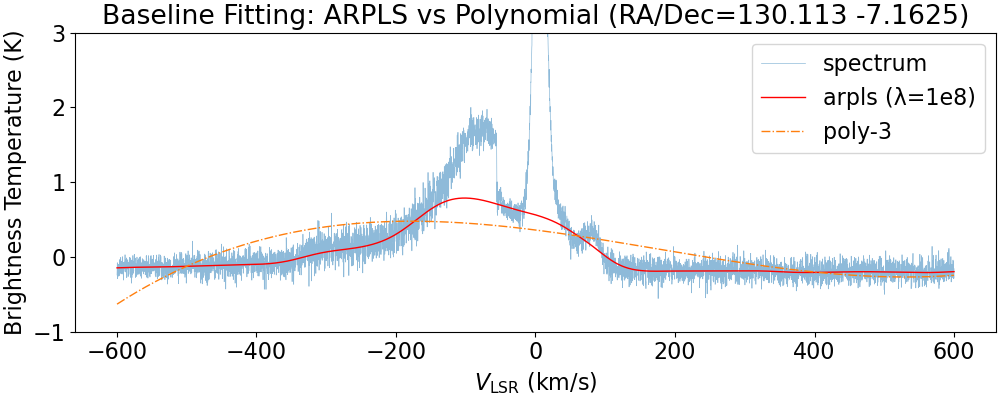

In [7]:
spectrum2 = data[:, 233, 395]
sky2 = cube.wcs.celestial.pixel_to_world(395, 233)
print(sky2)

mask2 = (velocities < -20) | (velocities > 100)
v_masked2 = velocities[mask2]
spec_masked2 = spectrum2[mask2]

# ARPLS method
bkg2, params2 = Baseline(velocities).arpls(spectrum2, lam=1e8)

# Polynomial method
_, params2 = Baseline(v_masked2).poly(spec_masked2, poly_order=3, return_coef=True)
# recreate the polynomial using numpy and the full x-data
baseline_poly2 = np.polynomial.Polynomial(params2["coef"])(velocities)

fig = plt.figure(figsize=(10, 4), layout="constrained")
plt.plot(velocities, spectrum2, label="spectrum", lw=0.5, alpha=0.5)
plt.plot(velocities, bkg2, label="arpls (λ=1e8)", lw=1, color="red")
plt.plot(velocities, baseline_poly2, "-.", label="poly-3", lw=1)
plt.legend()
plt.xlabel(r"$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$", fontsize=16)
plt.ylabel("Brightness Temperature (K)", fontsize=16)
plt.ylim(-1, 3)
plt.title(f"Baseline Fitting: ARPLS vs Polynomial (RA/Dec={sky2.to_string('decimal')})")
plt.savefig("baseline_fitting_3.png", dpi=300)
plt.show()

In [8]:
# Use ARPLS seperately on positive and negative velocity ranges
spec_neg2 = spectrum2[(velocities < -50)]
vel_neg2 = velocities[(velocities < -50)]
bkg_neg2 = Baseline(vel_neg).arpls(spec_neg2, lam=1e8)[0]

spec_pos2 = spectrum2[(velocities > 100)]
vel_pos2 = velocities[(velocities > 100)]
bkg_pos2 = Baseline(vel_pos2).arpls(spec_pos2, lam=1e8)[0]

# Combine the two baselines with NaNs in the masked regions
bkg_combined2 = np.full_like(spectrum2, np.nan, dtype=float)
bkg_combined2[(velocities < -50)] = bkg_neg2
bkg_combined2[(velocities > 100)] = bkg_pos2

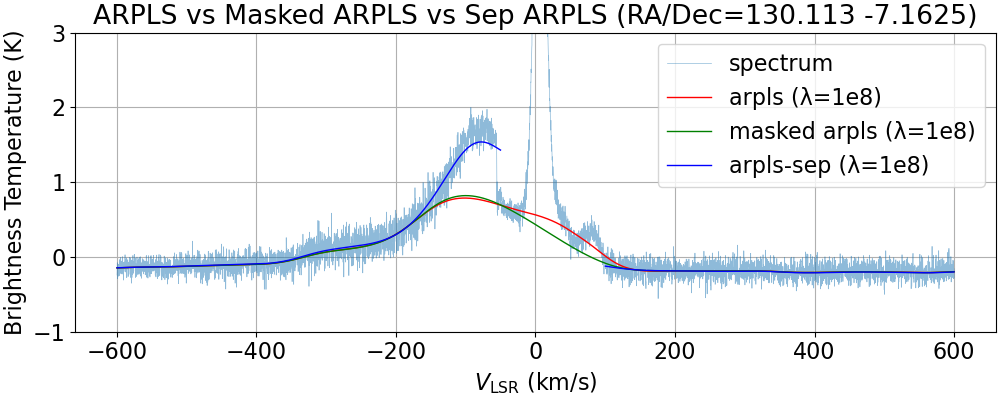

In [ ]:
# ARPLS method vs Masked ARPLS method vs Separated ARPLS method

bkg_masked2 = masked_arpls(spectrum2, mask=mask2, lam=1e8)

fig = plt.figure(figsize=(10, 4), layout="constrained")
plt.plot(velocities, spectrum2, label='spectrum', lw=0.5, alpha=0.5)
plt.plot(velocities, bkg2, label='arpls (λ=1e8)', lw=1, color='red')
plt.plot(velocities, bkg_masked2, label='masked arpls (λ=1e8)', lw=1, color='green')
plt.plot(velocities, bkg_combined2, label='sep arpls (λ=1e8)', lw=1, color='blue')
plt.legend()
plt.xlabel(r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$')
plt.ylabel('Brightness Temperature (K)')
plt.ylim(-1, 3)
plt.title(f'ARPLS vs Masked ARPLS vs Sep ARPLS (RA/Dec={sky2.to_string("decimal")})')
plt.grid()
plt.savefig('baseline_fitting_4.png', dpi=300)
plt.show()